# Intelligent Network Intrusion Detection System using Machine Learning

This notebook demonstrates the implementation of a Machine Learning-based Intrusion Detection System (IDS) following the schema of the popular **CICIDS2017** dataset.

## Objectives:
1. **Exploratory Data Analysis (EDA)**
2. **Data Preprocessing & Feature Engineering**
3. **Handling Class Imbalance using SMOTE**
4. **Feature Selection & Correlation Analysis**
5. **Comparative Evaluation of 4 ML Algorithms**:
   - Random Forest Classifier
   - XGBoost Classifier
   - LightGBM Classifier
   - Support Vector Machine (SVM)
6. **Evaluation Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix
7. **Comparative Inference Speed Analysis**
8. **SHAP-based Explainability Analysis**

In [1]:
# 1. Import required libraries
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

import shap

sns.set_theme(style='darkgrid', palette='muted')
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load & Explore Dataset

We first generate/load a representative sample of network traffic based on the CICIDS2017 feature and class definitions.

In [2]:
# Run dataset_generator if not already generated
if not os.path.exists('cicids2017_sample.csv'):
    from dataset_generator import generate_synthetic_cicids2017
    df = generate_synthetic_cicids2017(6000)
    df.to_csv('cicids2017_sample.csv', index=False)
else:
    df = pd.read_csv('cicids2017_sample.csv')

print(f"Dataset loaded. Shape: {df.shape}")
df.head()

Dataset loaded. Shape: (6000, 16)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Packet Length Mean,Packet Length Std,Init_Win_bytes_forward,Init_Win_bytes_backward,Label
0,80,19020.885440,13,19,1245.354185,6379.673262,100.663082,227.821085,400876.577010,1682.361218,594.402670,176.163147,62.451403,32980,4017,BENIGN
1,5789,145978.201877,24,31,2181.386488,3067.368402,75.056086,73.648706,35955.744230,376.768581,2654.149125,74.262836,0.697967,8192,8192,Botnet
2,443,4333.590806,35,1,1064.945221,11.875827,20.018825,19.261883,248482.400879,8307.198722,120.377522,19.997799,0.124393,1024,0,DoS
3,22,13900.146576,18,18,1352.468119,7705.691238,80.037331,236.095174,651659.269053,2589.900747,386.115183,158.066253,78.028922,49934,42260,BENIGN
4,80,144132.849342,18,17,1523.155967,1989.756421,69.737739,193.585050,24372.739486,242.831528,4118.081410,129.892147,61.898376,24044,13926,BENIGN


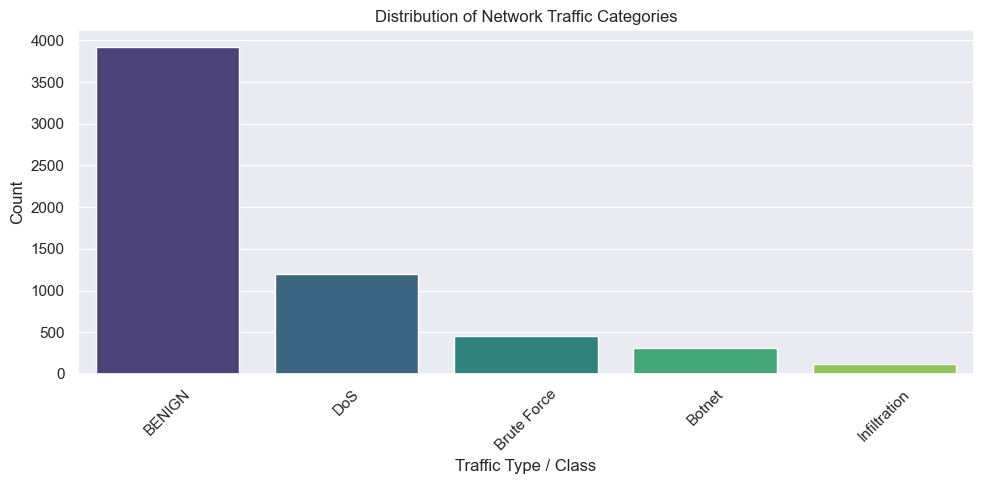

In [3]:
# Class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Label', order=df['Label'].value_counts().index, palette='viridis')
plt.title('Distribution of Network Traffic Categories')
plt.ylabel('Count')
plt.xlabel('Traffic Type / Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Preprocessing & Feature Correlation

Let's visualize the correlation among network features.

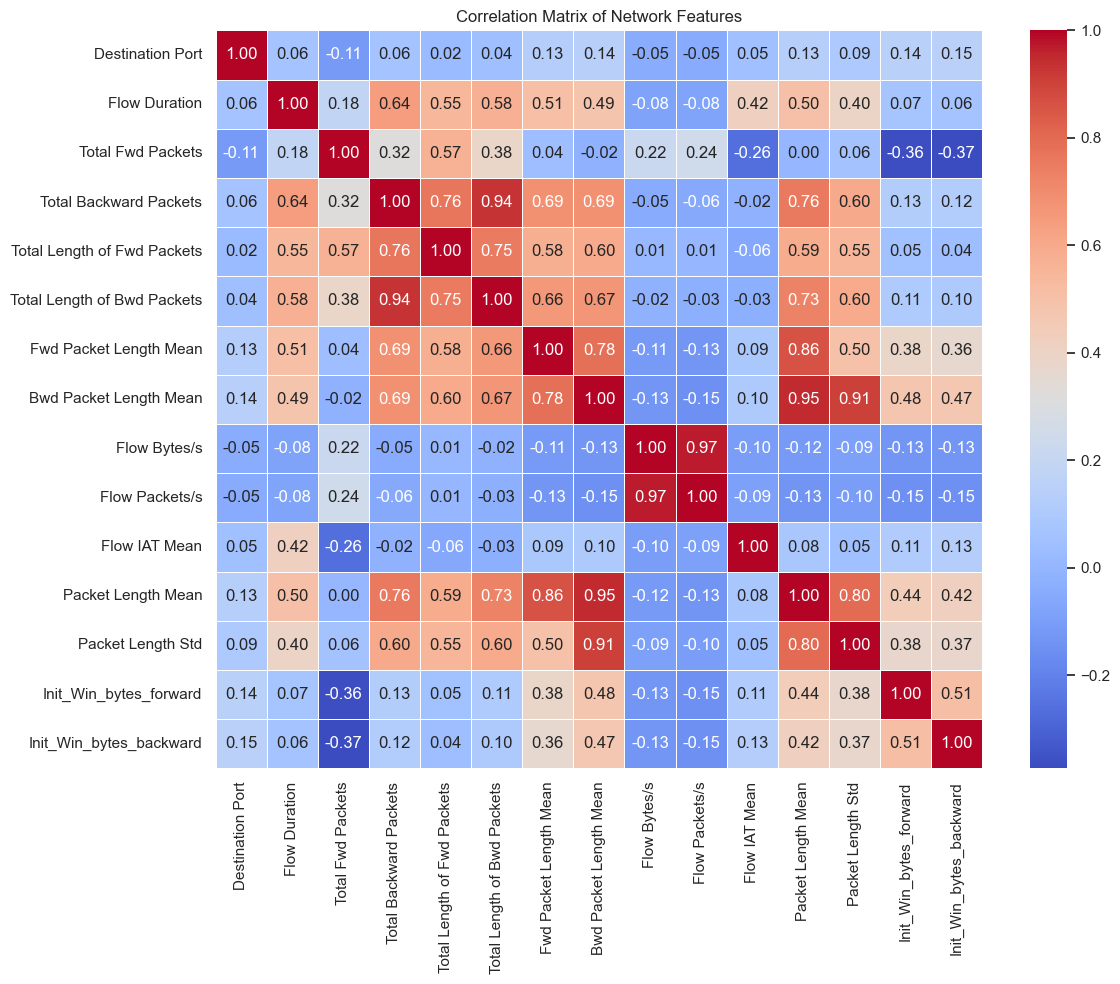

In [4]:
# Calculate correlation matrix
corr_matrix = df.drop(columns=['Label']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Network Features')
plt.tight_layout()
plt.show()

In [5]:
# Prepare features and encode target classes
X = df.drop(columns=['Label'])
y = df['Label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split (stratified to maintain ratio of attack classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shapes:", X_train_scaled.shape)
print("Testing shapes:", X_test_scaled.shape)

Training shapes: (4800, 15)
Testing shapes: (1200, 15)


## 4. Handling Class Imbalance using SMOTE

Since network datasets are highly imbalanced (mostly BENIGN traffic), we utilize Synthetic Minority Over-sampling Technique (SMOTE) to balance minority attack classes in training set.

In [6]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Original training labels distribution:")
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {label_encoder.inverse_transform([u])[0]}: {c}")

print("\nResampled training labels distribution (SMOTE):")
for u, c in zip(*np.unique(y_train_res, return_counts=True)):
    print(f"  {label_encoder.inverse_transform([u])[0]}: {c}")

Original training labels distribution:
  BENIGN: 3139
  Botnet: 251
  Brute Force: 361
  DoS: 955
  Infiltration: 94

Resampled training labels distribution (SMOTE):
  BENIGN: 3139
  Botnet: 3139
  Brute Force: 3139
  DoS: 3139
  Infiltration: 3139


## 5. Comparative Evaluation of ML Models

We train and benchmark the 4 classifiers.

In [7]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"=== Training {name} ===")
    start_time = time.time()
    model.fit(X_train_res, y_train_res)
    train_time = time.time() - start_time
    
    # Inference speed benchmark
    start_inf = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    inf_time = time.time() - start_inf
    
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    
    results[name] = {
        'Model': name,
        'Accuracy': acc,
        'ROC-AUC': roc_auc,
        'Training Time (s)': train_time,
        'Inference Speed (us/pkt)': (inf_time / len(X_test_scaled)) * 1e6,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    trained_models[name] = model

=== Training Random Forest ===
=== Training XGBoost ===
=== Training LightGBM ===
=== Training SVM ===


In [8]:
# Compare Metrics in a Table
comparison_df = pd.DataFrame(results).T.drop(columns=['y_pred', 'y_prob'])
comparison_df

,Model,Accuracy,ROC-AUC,Training Time (s),Inference Speed (us/pkt)
Random Forest,Random Forest,1.0,1.0,0.483682,104.88828
XGBoost,XGBoost,1.0,1.0,0.516309,4.167557
LightGBM,LightGBM,0.999167,1.0,2.609366,19.647479
SVM,SVM,0.9975,1.0,3.873628,341.568987


### Confusion Matrices

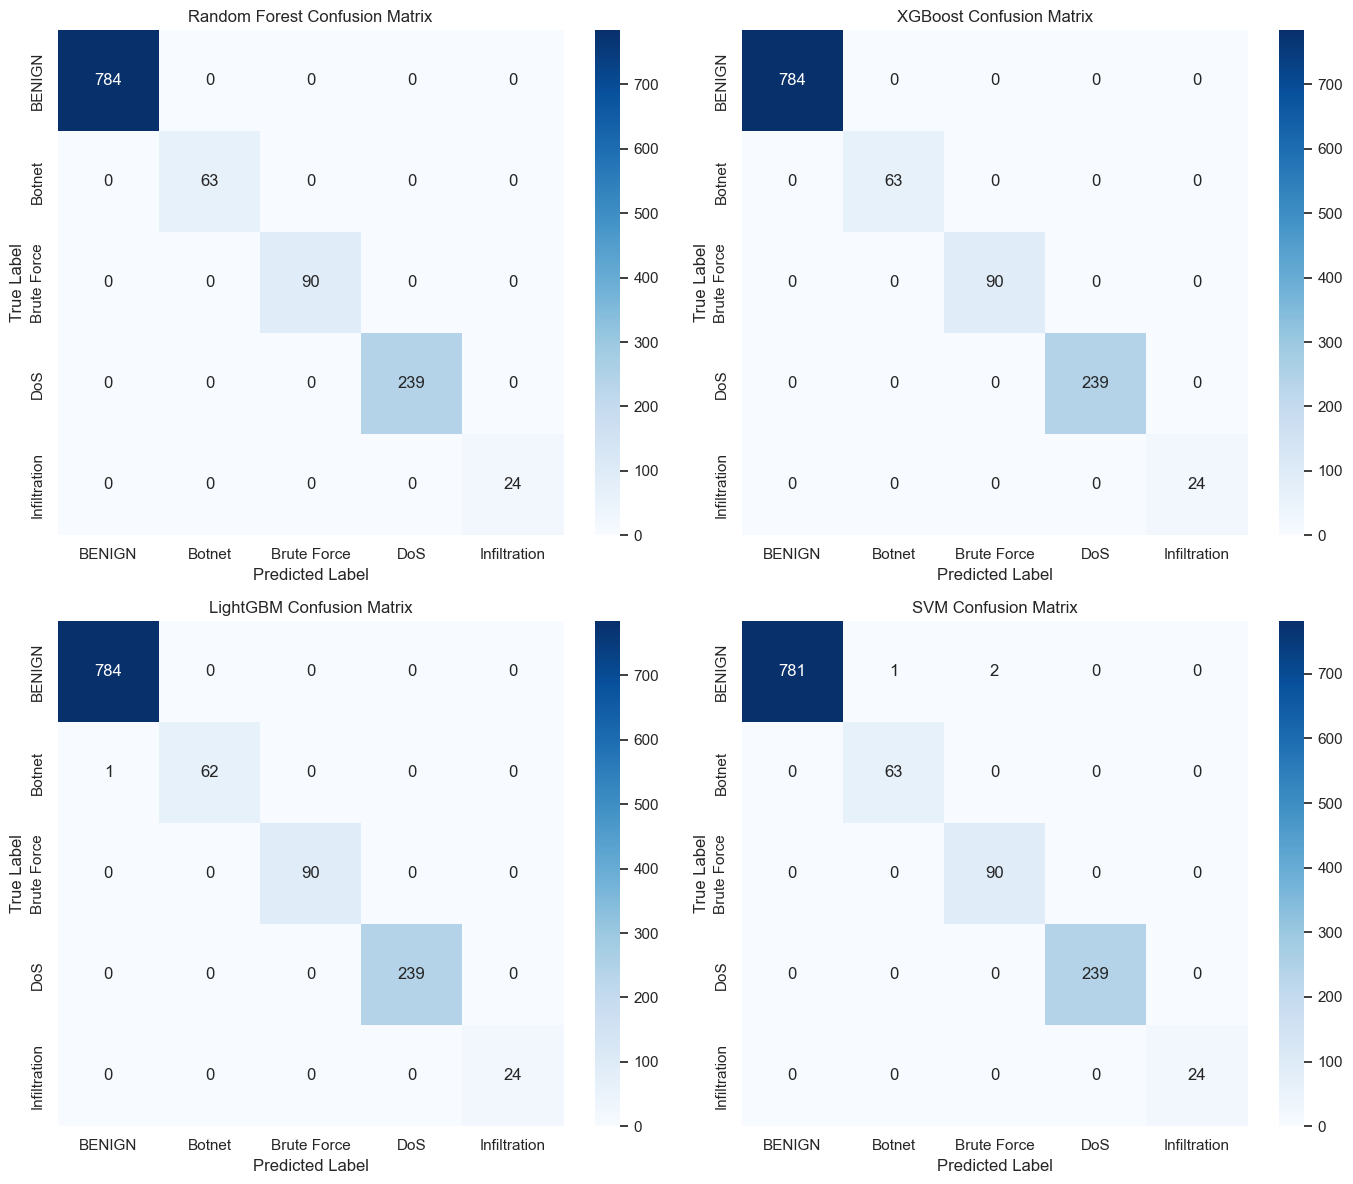

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')
    
plt.tight_layout()
plt.show()

## 6. SHAP-based Explainability Analysis

We use SHAP (SHapley Additive exPlanations) to explain feature contributions for the Random Forest classifier.

Computing SHAP values using TreeExplainer...
SHAP summary plot for first class:


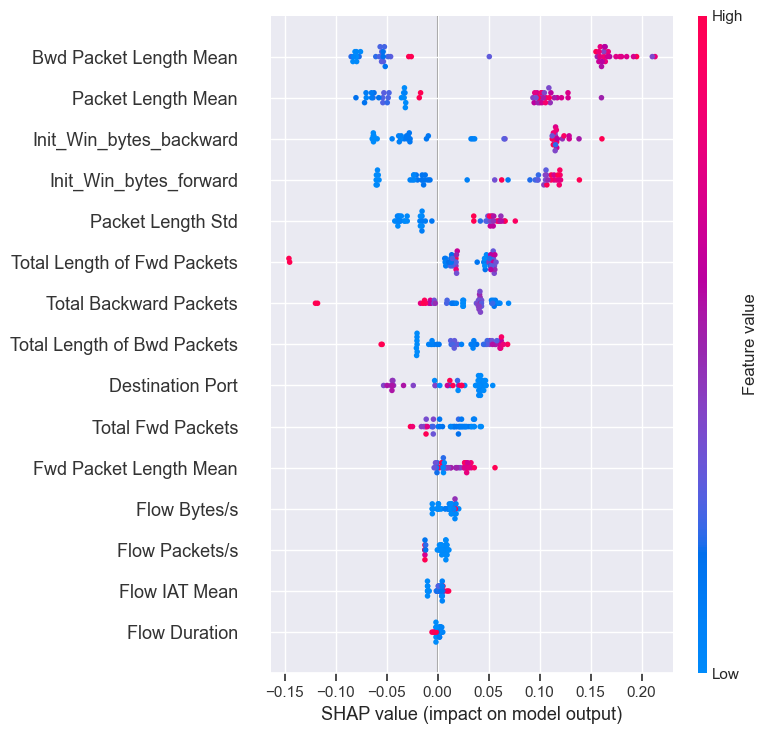

In [10]:
print("Computing SHAP values using TreeExplainer...")
import shap
explainer = shap.TreeExplainer(trained_models['Random Forest'])

sample_indices = np.random.choice(len(X_test_scaled), size=50, replace=False)
X_sample = X_test_scaled[sample_indices]

shap_values = explainer.shap_values(X_sample)

print("SHAP summary plot for first class:")
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_sample, feature_names=X.columns)
elif hasattr(shap_values, 'values') and shap_values.values.ndim == 3:
    shap.summary_plot(shap_values.values[:, :, 0], X_sample, feature_names=X.columns)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap.summary_plot(shap_values[:, :, 0], X_sample, feature_names=X.columns)
else:
    shap.summary_plot(shap_values, X_sample, feature_names=X.columns)